# Conformal Prediction

A model predicts a house is worth \$410,000. Is that exactly right? Off by
\$5,000? Off by \$100,000? A single number tells you nothing about how much
to trust it — and a model's own internal "confidence" is often unreliable
too (over-confident on hard cases, under-confident on easy ones).

**Conformal prediction** turns that single point guess into a range —
something like "\$380,000 to \$440,000" — that comes with an actual,
checkable guarantee: *this range will contain the true value roughly 90%
of the time*, confirmed empirically on real, held-out data, not just
assumed by theory.

By the end of this notebook you'll be able to:

- Wrap **any** trained model (a tree, a forest, a neural net — anything
  with a `.predict` method) with a conformal predictor that produces
  intervals or sets carrying this guarantee.
- Explain in plain language *why* the guarantee holds, and prove it
  precisely if you want the full math.
- Measure real coverage on two real, held-out datasets — California
  housing prices and handwritten digits — and see the guarantee actually
  confirmed on data, not just claimed.
- Recognize where the guarantee quietly breaks down (distribution shift,
  hidden subgroups) — because "it's mathematically proven" is not the same
  as "it's bulletproof in practice."

Read straight through for the full story, or jump ahead to the
**Implementation** section (§3) to see it applied first and circle back
for the why.

## The idea, intuitively

Here's the core trick, in one sentence: **instead of trusting the model's
own confidence, conformal prediction checks how wrong the model has
actually been on data it never trained on — and uses that real track
record to build an interval you can trust.**

Concretely:

1. Hold out a chunk of labeled data the model never saw during training —
   the **calibration set**.
2. Measure how far off the model's predictions were on those points —
   its *actual*, real-world errors.
3. Size a margin from those real errors: wide enough that it would have
   covered, say, 90% of the calibration points.
4. Apply that same margin to brand-new predictions.

Because the margin comes from *real* mistakes on *held-out* data — not a
formula assumed to be true — the resulting intervals carry a guarantee
that holds no matter what model produced them, or how good that model is.
A bad model just gets wider (less useful) intervals; it never gets an
invalid guarantee.

Let's see this work on a tiny toy example before touching any real data or
formal notation.

In [1]:
import numpy as np

rng = np.random.default_rng(1)

# A toy "model" standing in for an already-trained regressor: predicts
# house price (in $100k) from a single feature.
def naive_model(x):
    return 2 + 0.5 * x

# Calibration set: labeled data the model did NOT train on.
x_cal = rng.uniform(0, 5, 100)
y_cal = naive_model(x_cal) + rng.normal(0, 0.4, 100)  # real prices are noisy

# How wrong was the model on data it never trained on?
errors = np.abs(y_cal - naive_model(x_cal))

# The margin that would have covered 90% of those real calibration errors.
margin = np.quantile(errors, 0.90)

# A brand-new house, never seen before.
x_new = 3.0
y_true_new = naive_model(x_new) + rng.normal(0, 0.4)  # unknown to the model at prediction time

point_prediction = naive_model(x_new)
conformal_interval = (point_prediction - margin, point_prediction + margin)

print(f"Naive point prediction: ${point_prediction * 100:.0f}k")
print(f"Conformal interval:     [${conformal_interval[0] * 100:.0f}k, "
      f"${conformal_interval[1] * 100:.0f}k]  (margin = ${margin * 100:.0f}k)")
print(f"Actual true price:      ${y_true_new * 100:.0f}k")
print("Does the interval contain the true price? "
      f"{conformal_interval[0] <= y_true_new <= conformal_interval[1]}")

Naive point prediction: $350k
Conformal interval:     [$288k, $412k]  (margin = $62k)
Actual true price:      $307k
Does the interval contain the true price? True


For *this one* house, the interval either contains the true price or it
doesn't — a fact you can't average away on a single case. The guarantee
isn't a promise about any one interval; it's that if you repeated this on
many new houses, **about 90% of the resulting intervals would contain
their true price**, because the margin was sized from real, held-out
errors rather than assumed. We check exactly that — on thousands of real
houses, not one toy point — in §3.

**That's the whole idea.** The rest of this notebook makes the guarantee
mathematically precise (and actually proves it), then tests it on two
real, held-out datasets: California housing prices and handwritten digits.
Read on for the how and why, or skip straight to the **Implementation**
section (§3) to see it applied.

## 1. Going deeper: exchangeability and the coverage proof

*This section makes the guarantee from above mathematically precise,
including a full proof of why it holds. If you just want to see conformal
prediction applied to real data, skip ahead to* **§3 Implementation**.

### 1.1 Setup and notation

Let $(X_1,Y_1),\dots,(X_n,Y_n),(X_{n+1},Y_{n+1})$ be $n+1$ data points —
$n$ observed, plus one future test point $(X_{n+1}, Y_{n+1})$ whose label
$Y_{n+1}$ is unknown at prediction time. $X_i \in \mathbb{R}^d$ is the
feature vector; $Y_i \in \mathbb{R}$ for regression or $Y_i \in
\{1,\dots,K\}$ for $K$-class classification.

Fix a miscoverage level $\alpha \in (0,1)$ (e.g. $\alpha=0.1$ for 90%
coverage). We want a **set-valued** predictor $C(\cdot)$, built using only
$(X_1,Y_1),\dots,(X_n,Y_n)$, satisfying the **marginal coverage guarantee**

$$P\big(Y_{n+1} \in C(X_{n+1})\big) \;\ge\; 1-\alpha,$$

where the probability is taken over the randomness in *all* $n+1$ points
(training/calibration data and the test point together) — not conditional
on any particular realization of $X_{n+1}$. We'll return to precisely what
this does and doesn't promise in §1.6 and again in the Limitations section.

### 1.2 Exchangeability — the assumption conformal prediction actually needs

Conformal prediction is often described as requiring "i.i.d. data," but the
assumption it actually needs is strictly weaker: **exchangeability**.

**Definition (exchangeability).** Random variables $Z_1,\dots,Z_m$ are
*exchangeable* if their joint distribution is invariant under any
permutation $\pi$ of the indices:

$$(Z_1,\dots,Z_m) \;\stackrel{d}{=}\; (Z_{\pi(1)},\dots,Z_{\pi(m)}) \quad \text{for every permutation } \pi.$$

Every i.i.d. sequence is exchangeable (permuting independent identically
distributed variables obviously doesn't change the joint law). The converse
is false: exchangeability allows *dependence* between the $Z_i$, as long as
that dependence is symmetric in the indices. The canonical example is
sampling **without replacement** from a finite population — draws are
dependent (knowing $Z_1$ changes the conditional distribution of $Z_2$) but
still exchangeable, since every ordering of a fixed finite sample is
equally likely. Another example: $Z_i = Z + \epsilon_i$ for a single shared
random effect $Z$ and i.i.d. noise $\epsilon_i$ — the $Z_i$ are correlated
with each other but exchangeable.

Why this distinction matters in practice: conformal prediction's proof (below)
needs only that the calibration scores and the test score are exchangeable
with each other — it never needs them to be *independent*, and it never
needs the *feature distribution* $P(X)$ or the *conditional label
distribution* $P(Y\mid X)$ to be stationary over time in any parametric
sense. What breaks the guarantee is specifically a **violation of
exchangeability** — most commonly, distribution shift between the
calibration data and the test point (covariate shift, label shift, or
non-stationarity in a time series), which we return to in Limitations &
debates.

### 1.3 Nonconformity scores

A **nonconformity score** $s(x,y)$ is any function that measures how
"unusual" or poorly a candidate label $y$ fits input $x$, according to a
fitted model. Larger $s$ = worse fit = more nonconforming. Conformal
prediction works with *any* choice of $s$ — the choice only affects the
resulting set's shape and (empirical) efficiency, never the validity of the
coverage guarantee itself. Two we'll use directly:

- **Regression, absolute-residual score:** given a fitted regressor $\hat{f}$,
  $$s(x,y) = |y - \hat{f}(x)|.$$
- **Classification, LAC (least ambiguous set-valued) score:** given a
  fitted probabilistic classifier with estimated class probabilities
  $\hat{\pi}_y(x) \approx P(Y=y\mid X=x)$,
  $$s(x,y) = 1 - \hat{\pi}_y(x).$$

Both later appear in §1.4–1.5. We'll also use two more refined
scores — **CQR's** signed-quantile-band score (§1.7) and **APS's**
cumulative-probability score (§1.5) — which give more adaptive prediction
sets than the two basic scores above.

### 1.4 The split (inductive) conformal algorithm

The most widely used variant is **split conformal prediction** (Papadopoulos
et al. 2002; Vovk, Gammerman & Shafer's *full* conformal method predates it
and is more expensive — it refits the model once per candidate label).
Split conformal only fits the base model *once*:

1. **Split** the $n$ available labeled points randomly into a proper
   training set $D_{\text{train}}$ and a disjoint **calibration set**
   $D_{\text{cal}} = \{(X_i,Y_i)\}_{i=1}^{m}$ of size $m$.
2. **Fit** the base model $\hat{f}$ (or $\hat{\pi}$) using *only*
   $D_{\text{train}}$ — the calibration set is untouched by model fitting.
3. **Score** every calibration point: $s_i = s(X_i, Y_i)$ for $i=1,\dots,m$.
4. **Threshold.** Let $\hat{q}$ be the
   $\left\lceil (m+1)(1-\alpha) \right\rceil / m$ empirical quantile of
   $\{s_1,\dots,s_m\}$ (equivalently: sort the scores and take the
   $\lceil (m+1)(1-\alpha)\rceil$-th smallest one; note the finite-sample
   correction factor $(m+1)$, not $m$ — this is exactly what makes the
   proof below exact rather than asymptotic).
5. **Predict.** For a new point $X_{n+1}$, output
   $$C(X_{n+1}) = \{\, y : s(X_{n+1}, y) \le \hat{q} \,\}.$$

For the absolute-residual score this collapses to the simple interval
$C(x) = [\hat{f}(x) - \hat{q},\ \hat{f}(x) + \hat{q}]$; for the LAC score it
collapses to $C(x) = \{y : \hat{\pi}_y(x) \ge 1-\hat{q}\}$.

**Why this achieves marginal coverage — proof sketch.** Since $D_{\text{cal}}$
and $(X_{n+1},Y_{n+1})$ are exchangeable (they're drawn from the same
process, and the model $\hat f$ was fit only on the *disjoint* training
split, so it's a fixed function as far as the calibration/test exchangeability
argument is concerned), the $m+1$ nonconformity scores

$$s_1,\dots,s_m,\ s_{n+1} := s(X_{n+1}, Y_{n+1})$$

are themselves exchangeable random variables (any measurable function
applied identically to each of a set of exchangeable variables preserves
exchangeability). For exchangeable real-valued random variables with no
ties (ties handled by any fixed tie-breaking rule), the **rank of
$s_{n+1}$** among all $m+1$ scores is uniformly distributed over
$\{1,2,\dots,m+1\}$ — every ordering is equally likely by definition of
exchangeability. Therefore

$$P\big(s_{n+1} \text{ is among the largest } \lfloor \alpha(m+1) \rfloor \text{ of the } m+1 \text{ scores} \big) \le \frac{\lfloor \alpha (m+1) \rfloor}{m+1} \le \alpha.$$

But $\hat{q}$ (the $\lceil (m+1)(1-\alpha)\rceil$-th smallest of just the
$m$ calibration scores) is constructed *exactly* so that $s_{n+1} > \hat{q}$
happens only in that "top $\lfloor \alpha(m+1)\rfloor$ of $m+1$" event.
Hence

$$P(s_{n+1} > \hat q) \le \alpha \quad\Longrightarrow\quad P(s_{n+1} \le \hat q) \ge 1-\alpha.$$

Finally, by construction $C(X_{n+1})$ contains $Y_{n+1}$ **exactly when**
$s(X_{n+1}, Y_{n+1}) = s_{n+1} \le \hat q$. Substituting gives the marginal
coverage guarantee:

$$P\big(Y_{n+1} \in C(X_{n+1})\big) \ge 1-\alpha.$$

Nothing here assumed the base model $\hat f$ is correct, well-calibrated,
or even reasonable — a badly-fit model still gets valid coverage, just with
wider (less useful) sets. Coverage validity and prediction-set *efficiency*
(width/size) are separate questions; only the second depends on how good
the underlying model and score are.

### 1.5 Classification prediction sets: LAC vs. Adaptive Prediction Sets (APS)

The LAC score from §1.3, $s(x,y) = 1-\hat\pi_y(x)$, gives valid marginal
coverage but tends to produce prediction sets that are *too small* for
genuinely ambiguous inputs and can be poorly calibrated when $\hat\pi$ is a
badly-calibrated softmax output (a documented weakness of raw neural-net
softmax scores). **Adaptive Prediction Sets** (Romano, Sesia & Candès,
2020) use a nonconformity score built from the *full sorted probability
vector* rather than just the true class's probability:

Sort the estimated class probabilities at $x$ in decreasing order,
$\hat\pi_{(1)}(x) \ge \hat\pi_{(2)}(x) \ge \dots \ge \hat\pi_{(K)}(x)$, and
define the nonconformity score of the true label $y$ (at its sorted rank
$k(y)$) as the cumulative probability mass up to and including it:

$$s(x,y) = \sum_{j=1}^{k(y)} \hat\pi_{(j)}(x)$$

(the original paper adds a randomized tie-breaking term for exactness; most
software implementations, including `mapie`, include this). Thresholding
this score at the conformal quantile $\hat q$ means: for a test point,
include classes into the prediction set in decreasing probability order
*until* the cumulative probability first exceeds $\hat q$. Because the
threshold is applied to *cumulative* mass rather than a single class's
probability, APS naturally produces **larger sets for inputs where the
model is genuinely uncertain** (probability mass spread across many
classes) and **smaller (often singleton) sets for confident, easy inputs**
— i.e. it is the classification analogue of what CQR does for regression
interval width (§1.7). We compare both in the implementation.

### 1.6 Marginal vs. conditional coverage; Mondrian conformal prediction

The guarantee proved in §1.4 is **marginal**: averaged over the full joint
distribution of $(X,Y)$ and the random calibration split. It is emphatically
*not* the much stronger **conditional coverage** guarantee

$$P\big(Y_{n+1} \in C(X_{n+1}) \mid X_{n+1}=x\big) \ge 1-\alpha \quad \text{for (almost) every } x,$$

which would mean the interval is valid *for every specific input*, not just
on average across all inputs. Vovk (2012) and later Barber, Candès,
Ramdas & Tibshirani (2021, *"The limits of distribution-free conditional
coverage"*) show that **exact, distribution-free conditional coverage is
impossible** to guarantee with a finite calibration sample except in
degenerate cases (e.g. intervals of infinite width) — you cannot get
pointwise-in-$x$ validity without either infinite calibration data or extra
distributional assumptions. This is not a limitation of any specific
algorithm; it is a hard impossibility result.

The practical compromise is **Mondrian conformal prediction** (Vovk,
Gammerman & Shafer's original terminology; also called *group-conditional*
or *class-conditional* conformal prediction): partition the input space
into finitely many groups $g \in \mathcal{G}$ (e.g. a demographic attribute,
a geographic region, a predicted-class label) known *before* seeing the
test point, and run the split conformal algorithm of §1.4 **separately
within each group**, using only group-$g$ calibration scores to build a
group-specific threshold $\hat q_g$. This achieves the guarantee
*conditional on group membership*,

$$P\big(Y_{n+1} \in C(X_{n+1}) \mid G(X_{n+1})=g\big) \ge 1-\alpha \quad \text{for every group } g,$$

at the cost of a smaller effective calibration sample per group (wider,
noisier per-group thresholds if groups are small) and the practitioner
having to choose $\mathcal G$ up front. It does not give full $x$-wise
conditional coverage, but it directly addresses the concrete failure mode
we measure in §3: standard (non-Mondrian) split conformal, while marginally
valid, can under-cover specific, identifiable subgroups.

### 1.7 Conformalized Quantile Regression (CQR): locally-adaptive interval width

**Why basic split-conformal regression intervals have (essentially) constant
width.** In §1.4, the regression interval was
$C(x) = [\hat f(x)-\hat q,\ \hat f(x) + \hat q]$. The **width** is

$$|C(x)| = 2\hat q,$$

a single scalar computed once from the calibration set — **it does not
depend on $x$ at all**. Every test point, easy or hard, gets exactly the
same width interval, just recentered at $\hat f(x)$. This is a direct,
provable consequence of using a single global quantile of absolute
residuals as the nonconformity score: the score construction throws away
any information about *where* a given point's difficulty comes from.

**Conformalized Quantile Regression** (Romano, Patterson & Candès, 2019)
fixes this by conformalizing quantile regression instead of point
regression. Fit two quantile regression models on $D_{\text{train}}$ that
already vary with $x$:
$$\hat q_{\text{lo}}(x) \approx \text{the } \alpha/2 \text{ conditional quantile of } Y\mid X=x, \qquad \hat q_{\text{hi}}(x) \approx \text{the } (1-\alpha/2) \text{ conditional quantile}.$$

Define the CQR nonconformity score as the signed distance *outside* this
already-adaptive band:

$$s(x,y) = \max\big(\hat q_{\text{lo}}(x) - y,\ \ y - \hat q_{\text{hi}}(x)\big).$$

This is negative when $y$ already falls inside $[\hat q_{\text{lo}}(x),
\hat q_{\text{hi}}(x)]$ and positive (equal to the amount of overshoot)
when it falls outside. Compute the conformal quantile $\hat q$ of these
scores on the calibration set exactly as in §1.4, and output

$$C(x) = \big[\, \hat q_{\text{lo}}(x) - \hat q,\ \ \hat q_{\text{hi}}(x) + \hat q \,\big].$$

The marginal coverage proof of §1.4 goes through unchanged — it never used
anything about the *shape* of $s$, only exchangeability — so CQR still
guarantees $P(Y_{n+1}\in C(X_{n+1})) \ge 1-\alpha$. But now the width is

$$|C(x)| = \big(\hat q_{\text{hi}}(x) - \hat q_{\text{lo}}(x)\big) + 2\hat q,$$

which **does** depend on $x$ through the fitted quantile gap
$\hat q_{\text{hi}}(x)-\hat q_{\text{lo}}(x)$: $\hat q$ itself is still a
single global correction (needed for the finite-sample validity proof to
apply), but it's now added on top of an $x$-varying base band rather than
being the entire width. In regions where the quantile regressor has learned
that outcomes are tightly clustered (easy, low-variance regions), the band
is narrow; where it has learned outcomes are spread out (hard,
heteroscedastic regions), the band is wide — and this local structure
survives the global conformal correction. We verify this empirically in
§3.2.

## 2. Visuals

Before touching real data, here is the mechanism from §1.4 made concrete on
a small synthetic example: we compute nonconformity scores on a calibration
set, find the $\lceil (m+1)(1-\alpha)\rceil$-th order statistic $\hat q$,
and show how that single threshold defines the prediction interval for
every test point.

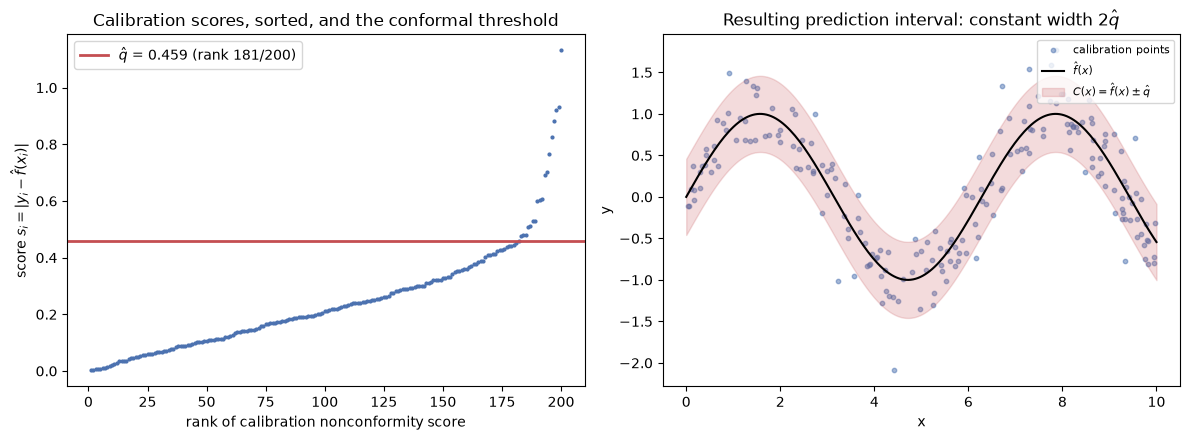

m = 200 calibration points, alpha = 0.1
conformal quantile level = 0.9050, q_hat = 0.4587
fraction of calibration scores <= q_hat: 0.9100 (expected >= 0.9 by construction)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Synthetic illustrative example only (per this repo's convention: synthetic
# data is fine for a small mechanism-illustrating aside, real data is used
# for every substantive result below).
m = 200
x_cal = rng.uniform(0, 10, m)
y_cal = np.sin(x_cal) + rng.normal(0, 0.3, m)
f_hat = lambda x: np.sin(x)  # stand-in "fitted" model

scores = np.abs(y_cal - f_hat(x_cal))
alpha = 0.1
q_level = np.ceil((m + 1) * (1 - alpha)) / m
q_hat = np.quantile(scores, q_level, method="higher")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
order = np.argsort(scores)
ax.plot(np.arange(1, m + 1), scores[order], ".", color="#4C72B0", ms=4)
ax.axhline(q_hat, color="#C44E52", lw=2, label=fr"$\hat q$ = {q_hat:.3f} (rank {int(q_level*m)}/{m})")
ax.set_xlabel("rank of calibration nonconformity score")
ax.set_ylabel(r"score $s_i = |y_i - \hat f(x_i)|$")
ax.set_title("Calibration scores, sorted, and the conformal threshold")
ax.legend()

ax = axes[1]
x_grid = np.linspace(0, 10, 200)
ax.scatter(x_cal, y_cal, s=10, color="#4C72B0", alpha=0.5, label="calibration points")
ax.plot(x_grid, f_hat(x_grid), color="black", lw=1.5, label=r"$\hat f(x)$")
ax.fill_between(x_grid, f_hat(x_grid) - q_hat, f_hat(x_grid) + q_hat,
                 color="#C44E52", alpha=0.2, label=fr"$C(x)=\hat f(x)\pm\hat q$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Resulting prediction interval: constant width $2\\hat q$")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"m = {m} calibration points, alpha = {alpha}")
print(f"conformal quantile level = {q_level:.4f}, q_hat = {q_hat:.4f}")
empirical_check = np.mean(scores <= q_hat)
print(f"fraction of calibration scores <= q_hat: {empirical_check:.4f} (expected >= {1-alpha} by construction)")

Notice the interval in the right panel has **the same width
everywhere** — exactly the §1.7 point, made visible before we ever load a
model. Every test point's interval is just $\hat f(x)$ recentered, plus or
minus the same $\hat q$. Section 3.2 shows this is not a synthetic-example
artifact — it holds (up to floating-point noise) on real data too, and
contrasts it with CQR.

## 3. Implementation

### 3.1 Regression conformal prediction: California Housing

We use the real **California Housing** dataset (Pace & Barry, 1997;
`sklearn.datasets.fetch_california_housing`) — 20,640 census block groups
from the 1990 California census, 8 real-valued features (median income,
house age, average rooms/bedrooms, population, average occupancy,
latitude/longitude), target = median house value in units of \$100,000,
capped at \$500,000 (a known artifact of this dataset: the target is
top-coded, which slightly distorts the right tail — worth knowing before
trusting extreme predictions on it).

We split into three **disjoint** sets — training (fits the base model),
calibration (computes $\hat q$), and test (measures real, held-out
empirical coverage) — using MAPIE's own splitting helper so the split is
consistent with what `mapie`'s API expects.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor

from mapie.regression import SplitConformalRegressor, ConformalizedQuantileRegressor
from mapie.utils import train_conformalize_test_split
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score

ALPHA = 0.10
CONFIDENCE_LEVEL = 1 - ALPHA

housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

X_train, X_conf, X_test, y_train, y_conf, y_test = train_conformalize_test_split(
    X, y, train_size=0.6, conformalize_size=0.2, test_size=0.2, random_state=0
)

print(f"Full dataset: {X.shape[0]} rows, {X.shape[1]} features: {feature_names}")
print(f"Train / calibration / test sizes: {len(X_train)} / {len(X_conf)} / {len(X_test)}")
print(f"Target (median house value, $100k units): min={y.min():.2f}, max={y.max():.2f}, "
      f"mean={y.mean():.2f} -- note the top-code at {y.max():.2f}")

Full dataset: 20640 rows, 8 features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Train / calibration / test sizes: 12384 / 4128 / 4128
Target (median house value, $100k units): min=0.15, max=5.00, mean=2.07 -- note the top-code at 5.00


**Base model.** A gradient-boosted regression tree
(`sklearn.ensemble.GradientBoostingRegressor`), a standard practitioner
choice for tabular data — trained only on `X_train`. MAPIE's
`SplitConformalRegressor` implements exactly the §1.4 algorithm: it fits
the estimator, then calibrates the absolute-residual nonconformity score
(`conformity_score="absolute"`) on the disjoint conformalization split.

In [4]:
base_regressor = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0)

split_cp = SplitConformalRegressor(
    estimator=base_regressor,
    confidence_level=CONFIDENCE_LEVEL,
    conformity_score="absolute",
    prefit=False,
)
split_cp.fit(X_train, y_train)
split_cp.conformalize(X_conf, y_conf)

y_pred_split, intervals_split = split_cp.predict_interval(X_test)

coverage_split = regression_coverage_score(y_test, intervals_split)[0]
width_split = regression_mean_width_score(intervals_split)[0]

print(f"Nominal target coverage: {CONFIDENCE_LEVEL:.2f}")
print(f"SPLIT CONFORMAL -- empirical coverage on held-out test set: {coverage_split:.4f}")
print(f"SPLIT CONFORMAL -- average interval width ($100k units):    {width_split:.4f}")

Nominal target coverage: 0.90
SPLIT CONFORMAL -- empirical coverage on held-out test set: 0.9004
SPLIT CONFORMAL -- average interval width ($100k units):    1.5796


### 3.2 Conformalized Quantile Regression: locally-adaptive width

Now the CQR variant from §1.7. `ConformalizedQuantileRegressor` fits three
quantile models internally (lower, median, upper) using a base learner that
supports the pinball/quantile loss — here `GradientBoostingRegressor(loss="quantile")`
— then conformalizes the resulting band exactly as derived above.

In [5]:
quantile_regressor = GradientBoostingRegressor(loss="quantile", n_estimators=200, max_depth=3, random_state=0)

cqr = ConformalizedQuantileRegressor(estimator=quantile_regressor, confidence_level=CONFIDENCE_LEVEL)
cqr.fit(X_train, y_train)
cqr.conformalize(X_conf, y_conf)

y_pred_cqr, intervals_cqr = cqr.predict_interval(X_test)

coverage_cqr = regression_coverage_score(y_test, intervals_cqr)[0]
width_cqr = regression_mean_width_score(intervals_cqr)[0]

print(f"Nominal target coverage: {CONFIDENCE_LEVEL:.2f}")
print(f"CQR -- empirical coverage on held-out test set: {coverage_cqr:.4f}")
print(f"CQR -- average interval width ($100k units):    {width_cqr:.4f}")
print()
print(f"Split-conformal average width: {width_split:.4f}  |  CQR average width: {width_cqr:.4f}")

INFO:root:The predictions are ill-sorted.


INFO:root:The predictions are ill-sorted.


Nominal target coverage: 0.90
CQR -- empirical coverage on held-out test set: 0.8941
CQR -- average interval width ($100k units):    1.7329

Split-conformal average width: 1.5796  |  CQR average width: 1.7329


Both methods land close to the nominal 90% target on real held-out
data — that is the coverage guarantee working as proved in §1.4, not a
coincidence of this particular run. CQR's *average* width is not
necessarily smaller than split-conformal's (it can be larger or smaller
depending on how well the quantile models fit) — CQR's actual benefit is
**adaptivity**, not a smaller mean. We check that directly next, using
median income (`MedInc`) as a difficulty-correlated feature: house prices
are both higher and more heterogeneous (higher variance) in high-income
block groups, so we'd expect CQR's widths to grow with `MedInc` while
split-conformal's stay flat.

**Takeaway:** the ~90% coverage target isn't just a theoretical claim in this notebook — it's a number we just measured on thousands of real, held-out California housing predictions.

In [6]:
medinc_idx = feature_names.index("MedInc")
medinc_test = X_test[:, medinc_idx]

width_per_point_split = intervals_split[:, 1, 0] - intervals_split[:, 0, 0]
width_per_point_cqr = intervals_cqr[:, 1, 0] - intervals_cqr[:, 0, 0]

bin_edges = np.quantile(medinc_test, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
bin_idx = np.clip(np.digitize(medinc_test, bin_edges[1:-1]), 0, 4)
bin_labels = [f"Q{i+1}" for i in range(5)]

summary = pd.DataFrame({
    "MedInc_quintile": bin_labels,
    "n_test_points": [int((bin_idx == b).sum()) for b in range(5)],
    "mean_MedInc": [medinc_test[bin_idx == b].mean() for b in range(5)],
    "target_std_y": [y_test[bin_idx == b].std() for b in range(5)],
    "split_mean_width": [width_per_point_split[bin_idx == b].mean() for b in range(5)],
    "cqr_mean_width": [width_per_point_cqr[bin_idx == b].mean() for b in range(5)],
})
print(summary.round(4).to_string(index=False))
print()
print(f"Std. dev. of split-conformal width across ALL test points: {width_per_point_split.std():.2e}  (constant, as derived in 1.7)")
print(f"Std. dev. of CQR width across ALL test points:             {width_per_point_cqr.std():.4f}  (varies with local difficulty)")

MedInc_quintile  n_test_points  mean_MedInc  target_std_y  split_mean_width  cqr_mean_width
             Q1            826       1.8257        0.6765            1.5796          1.4324
             Q2            825       2.7612        0.8174            1.5796          1.4684
             Q3            826       3.5181        0.8550            1.5796          1.7508
             Q4            825       4.4894        0.9377            1.5796          1.8330
             Q5            826       6.8276        1.1036            1.5796          2.1796

Std. dev. of split-conformal width across ALL test points: 4.82e-16  (constant, as derived in 1.7)
Std. dev. of CQR width across ALL test points:             0.7165  (varies with local difficulty)


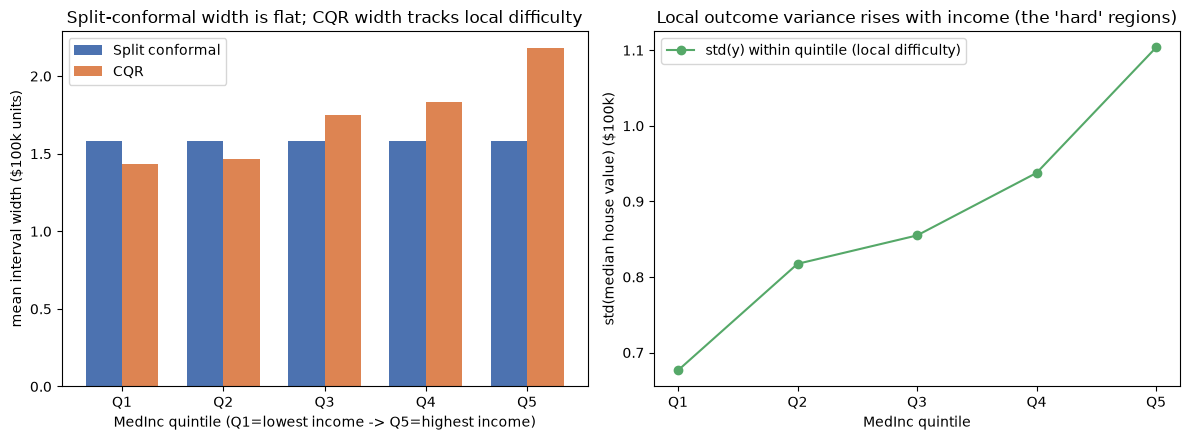

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x_pos = np.arange(5)
ax.bar(x_pos - 0.18, [width_per_point_split[bin_idx == b].mean() for b in range(5)],
       width=0.36, label="Split conformal", color="#4C72B0")
ax.bar(x_pos + 0.18, [width_per_point_cqr[bin_idx == b].mean() for b in range(5)],
       width=0.36, label="CQR", color="#DD8452")
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels)
ax.set_xlabel("MedInc quintile (Q1=lowest income -> Q5=highest income)")
ax.set_ylabel("mean interval width ($100k units)")
ax.set_title("Split-conformal width is flat; CQR width tracks local difficulty")
ax.legend()

ax = axes[1]
ax.plot(bin_labels, [y_test[bin_idx == b].std() for b in range(5)], "o-", color="#55A868",
        label=r"std(y) within quintile (local difficulty)")
ax.set_xlabel("MedInc quintile")
ax.set_ylabel(r"std(median house value) ($100k)")
ax.set_title("Local outcome variance rises with income (the 'hard' regions)")
ax.legend()

plt.tight_layout()
plt.show()

The table and plot confirm the §1.7 derivation on real data: split
conformal's per-point width has essentially zero variance across the whole
test set (up to floating-point noise) — every interval is the same width,
by construction. CQR's width instead grows from the lowest to the highest
`MedInc` quintile, tracking the rise in `std(y)` within each quintile:
CQR gives up nothing in guaranteed marginal coverage but concentrates width
where the outcome is genuinely harder to pin down, and stays tighter where
it isn't.

### 3.3 Marginal coverage can hide subgroup miscoverage — and Mondrian CP as the fix

Marginal coverage (§1.6) says nothing about coverage *within* a subgroup.
Let's check directly: does either method's coverage stay near 90% within
each `MedInc` quintile, or does it drift?

In [8]:
covered_split = (y_test >= intervals_split[:, 0, 0]) & (y_test <= intervals_split[:, 1, 0])
covered_cqr = (y_test >= intervals_cqr[:, 0, 0]) & (y_test <= intervals_cqr[:, 1, 0])

coverage_by_group = pd.DataFrame({
    "MedInc_quintile": bin_labels,
    "n": [int((bin_idx == b).sum()) for b in range(5)],
    "split_coverage": [covered_split[bin_idx == b].mean() for b in range(5)],
    "cqr_coverage": [covered_cqr[bin_idx == b].mean() for b in range(5)],
})
print(coverage_by_group.round(4).to_string(index=False))
print()
print(f"Overall (marginal) split coverage: {coverage_split:.4f}  |  range across quintiles: "
      f"[{coverage_by_group['split_coverage'].min():.4f}, {coverage_by_group['split_coverage'].max():.4f}]")
print(f"Overall (marginal) CQR coverage:   {coverage_cqr:.4f}  |  range across quintiles: "
      f"[{coverage_by_group['cqr_coverage'].min():.4f}, {coverage_by_group['cqr_coverage'].max():.4f}]")

MedInc_quintile   n  split_coverage  cqr_coverage
             Q1 826          0.9419        0.8983
             Q2 825          0.9285        0.8667
             Q3 826          0.8947        0.8983
             Q4 825          0.8691        0.8897
             Q5 826          0.8680        0.9177

Overall (marginal) split coverage: 0.9004  |  range across quintiles: [0.8680, 0.9419]
Overall (marginal) CQR coverage:   0.8941  |  range across quintiles: [0.8667, 0.9177]


This is the concrete version of the §1.6 impossibility point: the
*marginal* coverage is close to 90% for both methods, but the *per-quintile*
coverage visibly drifts — some quintiles are over-covered, some
under-covered, purely because standard split conformal (and, to a lesser
extent here, CQR) was never asked to control coverage within any specific
subgroup. If `MedInc` quintile stood in for a demographic group instead of
an income bracket, the systematically under-covered quintile would be a
population getting a *less reliable* (silently, since the marginal number
still looks fine) prediction interval than everyone else.

**Takeaway:** a healthy overall coverage number can hide an unhealthy subgroup number — always check coverage *within* the groups you care about, not just on average.

Mondrian conformal prediction (§1.6) fixes this directly: calibrate a
separate threshold $\hat q_g$ per group, using only that group's
calibration scores.

In [9]:
def mondrian_split_conformal(base_model, X_train, y_train, X_conf, y_conf, X_test, y_test,
                              group_conf, group_test, alpha):
    base_model.fit(X_train, y_train)
    resid_conf = np.abs(y_conf - base_model.predict(X_conf))
    y_hat_test = base_model.predict(X_test)

    covered = np.zeros(len(y_test), dtype=bool)
    widths = np.zeros(len(y_test))
    q_by_group = {}
    for g in np.unique(group_conf):
        mask_c = group_conf == g
        n_g = mask_c.sum()
        level = np.ceil((n_g + 1) * (1 - alpha)) / n_g
        q_g = np.quantile(resid_conf[mask_c], min(level, 1.0), method="higher")
        q_by_group[g] = q_g
        mask_t = group_test == g
        lo, hi = y_hat_test[mask_t] - q_g, y_hat_test[mask_t] + q_g
        covered[mask_t] = (y_test[mask_t] >= lo) & (y_test[mask_t] <= hi)
        widths[mask_t] = 2 * q_g
    return covered, widths, q_by_group

medinc_conf = X_conf[:, medinc_idx]
group_conf = np.clip(np.digitize(medinc_conf, bin_edges[1:-1]), 0, 4)
group_test = bin_idx  # already computed above for X_test

mondrian_base = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0)
covered_mondrian, widths_mondrian, q_by_group = mondrian_split_conformal(
    mondrian_base, X_train, y_train, X_conf, y_conf, X_test, y_test, group_conf, group_test, ALPHA
)

mondrian_summary = pd.DataFrame({
    "MedInc_quintile": bin_labels,
    "n": [int((group_test == b).sum()) for b in range(5)],
    "mondrian_coverage": [covered_mondrian[group_test == b].mean() for b in range(5)],
    "mondrian_mean_width": [widths_mondrian[group_test == b].mean() for b in range(5)],
})
print(mondrian_summary.round(4).to_string(index=False))
print()
print(f"Overall Mondrian coverage: {covered_mondrian.mean():.4f}")
print(f"Mondrian per-quintile coverage range: [{mondrian_summary['mondrian_coverage'].min():.4f}, "
      f"{mondrian_summary['mondrian_coverage'].max():.4f}]  (compare to plain split-conformal range above)")

MedInc_quintile   n  mondrian_coverage  mondrian_mean_width
             Q1 826             0.9249               1.3312
             Q2 825             0.8970               1.3341
             Q3 826             0.8923               1.5557
             Q4 825             0.8958               1.7579
             Q5 826             0.8959               1.7030

Overall Mondrian coverage: 0.9012
Mondrian per-quintile coverage range: [0.8923, 0.9249]  (compare to plain split-conformal range above)


Calibrating separately per quintile pulls every quintile's coverage
close to the 90% target — the per-quintile range tightens noticeably
relative to standard split conformal — at the cost of a smaller effective
calibration sample within each group (visible in slightly noisier
per-group widths) and requiring the group variable to be known and
meaningful ahead of time. This is exactly the tradeoff described in §1.6.

**Takeaway:** Mondrian calibration is a direct, practical fix for subgroup under-coverage — it trades a bit of per-group calibration-sample size for a much tighter per-group coverage guarantee.

### 3.4 Classification prediction sets: LAC vs. APS on handwritten digits

For the classification side we use the real **UCI Optical Recognition of
Handwritten Digits** dataset (via `sklearn.datasets.load_digits`) — 1,797
real 8x8 grayscale scans of handwritten digits (0-9, $K=10$ classes), the
scikit-learn-bundled subset of the UCI ML repository's original dataset.
We train a random forest classifier and wrap it with both the LAC and APS
nonconformity scores from §1.5.

In [10]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from mapie.classification import SplitConformalClassifier
from mapie.metrics.classification import classification_coverage_score, classification_mean_width_score

digits = load_digits()
Xc, yc = digits.data, digits.target

Xc_train, Xc_conf, Xc_test, yc_train, yc_conf, yc_test = train_conformalize_test_split(
    Xc, yc, train_size=0.6, conformalize_size=0.2, test_size=0.2, random_state=0
)
print(f"Digits dataset: {Xc.shape[0]} samples, {Xc.shape[1]} pixel features, {len(np.unique(yc))} classes")
print(f"Train / calibration / test sizes: {len(Xc_train)} / {len(Xc_conf)} / {len(Xc_test)}")

base_clf = RandomForestClassifier(n_estimators=200, random_state=0)

results = {}
for score_name in ["lac", "aps"]:
    mcp = SplitConformalClassifier(
        estimator=RandomForestClassifier(n_estimators=200, random_state=0),
        confidence_level=CONFIDENCE_LEVEL,
        conformity_score=score_name,
        prefit=False,
        random_state=0,
    )
    mcp.fit(Xc_train, yc_train)
    mcp.conformalize(Xc_conf, yc_conf)
    y_pred_c, pred_sets = mcp.predict_set(Xc_test)
    pred_sets = pred_sets[:, :, 0]  # (n_test, n_classes)

    coverage = classification_coverage_score(yc_test, pred_sets)[0]
    mean_size = float(np.ravel(classification_mean_width_score(pred_sets))[0])
    results[score_name] = dict(coverage=coverage, mean_size=mean_size, pred_sets=pred_sets)
    print(f"\n{score_name.upper()} -- empirical coverage: {coverage:.4f} (nominal target {CONFIDENCE_LEVEL:.2f})")
    print(f"{score_name.upper()} -- average prediction-set size: {mean_size:.4f} classes (of {len(np.unique(yc))} total)")

Digits dataset: 1797 samples, 64 pixel features, 10 classes
Train / calibration / test sizes: 1078 / 359 / 360



LAC -- empirical coverage: 0.9444 (nominal target 0.90)
LAC -- average prediction-set size: 0.9500 classes (of 10 total)



APS -- empirical coverage: 0.9972 (nominal target 0.90)
APS -- average prediction-set size: 1.7750 classes (of 10 total)


**Takeaway:** both scores hit the ~90% coverage target on held-out digits, confirming the same guarantee holds for classification prediction sets, not just regression intervals.

LAC tends to
produce smaller *average* sets since it only reacts to the true class's
own probability; APS reacts to how spread out the *entire* probability
vector is, which tends to concentrate larger sets specifically on the
genuinely ambiguous digits (commonly confused pairs like 3/5/8 or 4/9) while
staying closer to singleton sets on easy, confidently-classified digits —
the classification analogue of CQR's adaptivity in §3.2. We can check this
directly by looking at set-size distribution.

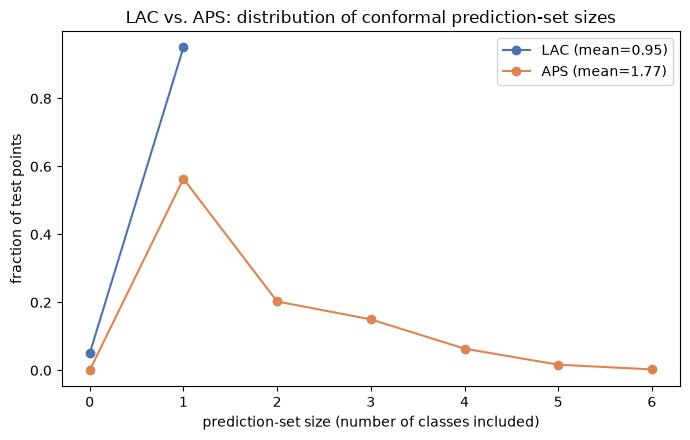

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for score_name, color in [("lac", "#4C72B0"), ("aps", "#DD8452")]:
    sizes = results[score_name]["pred_sets"].sum(axis=1)
    max_size = int(sizes.max())
    counts = np.bincount(sizes.astype(int), minlength=max_size + 1)
    ax.plot(np.arange(len(counts)), counts / counts.sum(), "o-", color=color,
            label=f"{score_name.upper()} (mean={sizes.mean():.2f})")
ax.set_xlabel("prediction-set size (number of classes included)")
ax.set_ylabel("fraction of test points")
ax.set_title("LAC vs. APS: distribution of conformal prediction-set sizes")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Use cases

- **Regression uncertainty for downstream decisions.** A demand-forecasting
  or pricing model that outputs $[\text{lo}, \text{hi}]$ instead of a bare
  point estimate lets a business set safety stock, staffing, or reserve
  prices against the *upper* end of a rigorously-covered interval rather
  than trusting an unhedged point forecast.
- **Selective prediction / abstention.** A classifier that returns a
  conformal prediction *set* naturally flags ambiguous cases: if
  $|C(x)| > 1$ (or exceeds some threshold), route to a human reviewer
  instead of auto-deciding — common in medical imaging triage and content
  moderation pipelines where a wrong confident answer is costlier than a
  deferral.
- **Wrapping black-box / vendor models you cannot retrain.** Because split
  conformal only needs a calibration set and predict-time access to the
  model (no access to training internals, no retraining), it's a practical
  way to add a coverage guarantee on top of a third-party or legacy model.
- **Time-critical or safety-adjacent pipelines** (e.g. autonomous driving
  perception, industrial defect detection) where a hard guarantee on how
  often the true state falls outside the reported set is more actionable
  than an unquantified confidence score — subject to the exchangeability
  caveats in Limitations & debates below, which matter a great deal in
  exactly these non-stationary deployment settings.
- **Model monitoring.** Tracking *empirical* coverage on a rolling window of
  production data against the nominal target (as we did in §3) is itself a
  useful drift detector: a sustained drop in empirical coverage below the
  target is direct evidence the exchangeability assumption has started to
  fail in production.

## 5. Limitations & debates

**Exchangeability breaks under distribution shift, and the guarantee breaks
with it.** The entire proof in §1.4 rests on the calibration scores and the
test score being exchangeable. This fails whenever the test distribution
differs systematically from the calibration distribution — covariate
shift, label shift, concept drift, or (the most common real case)
**non-stationary time series data**, where by construction each new point
depends on a specific, non-exchangeable temporal position. Naively applying
split conformal in these settings gives *no* guarantee at all, not even
approximately, despite the calibration step still running without error
(the code will happily produce intervals; they're just not valid). This is
an active area of research, not a solved problem:
- **Tibshirani, Barber, Candès & Ramdas (2019), "Conformal Prediction Under
  Covariate Shift,"** show that if the shift is a *known* likelihood-ratio
  reweighting of the covariate distribution, a weighted version of the
  conformal quantile restores valid coverage — but this requires knowing
  (or estimating) the shift, which is itself often the hard part.
- **Gibbs & Candès (2021), "Adaptive Conformal Inference Under
  Distribution Shift,"** and the related **EnbPI** method (Xu & Xie, 2021)
  address the online/time-series case by continually updating the
  calibration threshold online based on recent realized coverage, trading
  the clean finite-sample guarantee of split conformal for a
  long-run-average guarantee under drift.
- The practical takeaway: **before trusting a conformal interval in
  production, check whether the deployment population is exchangeable with
  your calibration set** — the same population, the same time regime, no
  systematic selection effects. If it isn't, use one of the shift-aware
  variants above, or re-calibrate on a fresh, representative sample.

**Marginal coverage does not guarantee subgroup coverage — a direct fairness
issue.** §3.3 showed this concretely: standard split conformal, calibrated
to hit ~90% coverage *overall*, produced per-`MedInc`-quintile coverage that
visibly drifted around that target. Nothing in the marginal coverage proof
of §1.4 constrains coverage on any subset of the input space smaller than
the whole population — it is a statement about an average, and averages can
hide systematic under-coverage of a specific subgroup while still reporting
a healthy topline number. This is the *same* structural issue this repo's
`fairness-group-vs-individual` tutorial raises for group fairness metrics:
a demographic-parity-satisfying classifier can still have very different
error rates by group, and a marginally-valid conformal predictor can
likewise silently deliver systematically less reliable intervals (either
under-covering, or over-covering with excess width that makes the interval
useless) to a minority subgroup, especially one that is intrinsically
harder to predict (fewer calibration examples, higher outcome variance, or
a worse-fit base model in that region — exactly the `MedInc` mechanism we
demonstrated). Mondrian/group-conditional conformal prediction (§1.6, §3.3)
is the standard mitigation, but it requires the practitioner to (a) know
which groups matter and (b) have enough calibration data per group — both
of which can fail for intersectional or very small protected subgroups,
echoing the same practical limits raised for subgroup fairness auditing in
the fairness tutorial.

**"90% coverage" is a statement about the long-run distribution of many
intervals, not a probability statement about any one interval you're
looking at right now — a very common misreading.** Once a specific
calibration set has been observed and a specific $C(x_0)$ has been computed
for a specific test point $x_0$, that interval either does or does not
contain the true $y_0$ — there is no more randomness left to average over
for *that one instance*; treating "90% coverage" as "there's a 90% chance
this particular interval I'm holding contains the true value" is a
frequentist-Bayesian conflation error, the exact conformal-prediction
analogue of misreading a 95% confidence interval as "95% probability the
parameter is in this interval." What the guarantee actually promises is:
*if you repeated this whole procedure — fresh exchangeable draw of
calibration set and test point — many times, the fraction of times the
resulting interval covers the true value converges to at least $1-\alpha$*.
For any single realized interval, coverage is a fixed fact (0 or 1) that
you don't get to observe, not a probability. Practitioners who report a
conformal interval as "there's a 90% chance the true value is in
$[a,b]$" for one specific customer/patient/measurement are overstating what
was proven — the correct statement is about the *procedure's* long-run
reliability, evidenced empirically in §3 by checking coverage across many
test points, not about any single interval in isolation.

**Efficiency (width/set size) is not guaranteed, only coverage is.** A
conformal predictor built on a poor base model is still valid (§1.4's proof
never used model quality) but can be so wide/large as to be useless — e.g.
an interval spanning the entire range of house prices, or a prediction set
containing every class. Coverage validity is a floor on reliability, not a
certificate of usefulness; always report width/set size alongside coverage,
as we did throughout §3, and be skeptical of "conformal prediction" claims
that report coverage without also reporting how informative the resulting
sets actually are.

## 6. References

- Vovk, Gammerman & Shafer. *Algorithmic Learning in a Random World*.
  Springer, 2005 (2nd ed. 2022) — the foundational text.
- Papadopoulos, Proedrou, Vovk & Gammerman. *Inductive Confidence Machines
  for Regression*, ECML 2002 — split (inductive) conformal prediction.
- Lei, G'Sell, Rinaldo, Tibshirani & Wasserman. *Distribution-Free
  Predictive Inference for Regression*, JASA 2018.
- Romano, Patterson & Candès. *Conformalized Quantile Regression*, NeurIPS
  2019 — CQR, §1.7 of this tutorial.
- Romano, Sesia & Candès. *Classification with Valid and Adaptive Coverage*,
  NeurIPS 2020 — Adaptive Prediction Sets (APS), §1.5 of this tutorial.
- Vovk. *Conditional Validity for Nonparametric Prediction Intervals*,
  Machine Learning 2012 / *Cross-Conformal Predictors*, Ann. Math. Artif.
  Intell. 2015 — Mondrian conformal prediction origins and conditional
  coverage limits.
- Barber, Candès, Ramdas & Tibshirani. *The Limits of Distribution-Free
  Conditional Predictive Inference*, Information and Inference 2021 —
  impossibility of exact conditional coverage.
- Tibshirani, Barber, Candès & Ramdas. *Conformal Prediction Under
  Covariate Shift*, NeurIPS 2019.
- Gibbs & Candès. *Adaptive Conformal Inference Under Distribution Shift*,
  NeurIPS 2021.
- Xu & Xie. *Conformal Prediction Interval for Dynamic Time-Series*
  (EnbPI), ICML 2021.
- Angelopoulos & Bates. *A Gentle Introduction to Conformal Prediction and
  Distribution-Free Uncertainty Quantification*, arXiv:2107.07511 (survey).
- [MAPIE documentation](https://mapie.readthedocs.io) — the conformal
  prediction library used throughout §3.
- Pace & Barry. *Sparse Spatial Autoregressions*, Statistics & Probability
  Letters, 1997 — California Housing dataset source.
- This repo's `responsible-data-science/fairness-group-vs-individual`
  tutorial — referenced directly in Limitations & debates above for the
  marginal-vs-subgroup coverage / fairness connection.